# Customer Segmentation and Churn Analysis Using RFM Modelling

### Phase 1: Environment Setup & Library Imports
In this section, we initialize our environment by importing essential data science and analytics libraries. We use `pandas` and `numpy` for data manipulation, and `matplotlib` along with `seaborn` for generating explanatory data visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Phase 2: Loading the Dataset
We load the raw transactional e-commerce dataset (`data.csv`). Because transactional data frequently contains non-standard characters, we apply `ISO-8859-1` encoding to ensure reliable data ingestion.

In [2]:
df_n= pd.read_csv("data.csv", encoding="ISO-8859-1")

### Phase 3: Initial Data Inspection
Let's print out the first few rows and check the overall dimensions of our dataframe to verify that the features (`InvoiceNo`, `StockCode`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`) loaded correctly.

In [3]:
df_n

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


### Phase 4: Missing Value Identification
To ensure accurate customer behavioral modeling, we check for missing values across all dimensions. Identifying rows with null values—particularly in critical fields like `CustomerID`—is vital for downstream calculations.

In [4]:
df_n.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Phase 5: Dropping Missing Demographics
Since transactional records without a valid `CustomerID` cannot be mapped back to unique customer accounts, we drop these records from the core dataset to maintain analytical integrity.

In [5]:
df=df_n.dropna(subset=['CustomerID'])
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Phase 6: Reviewing Cleaned Data
Let's print out the current dimensions and top records of the newly filtered dataframe (`df`) to observe the row reduction and confirm a clean starting frame.

In [6]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


### Phase 7: Standardizing Temporal Features
To calculate a customer's `Recency` correctly, the transaction dates must be treated as formal temporal objects. We cast the `InvoiceDate` string column into standard `datetime` objects.

In [7]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

C:\Users\bhash\AppData\Local\Temp\ipykernel_18256\3737639551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])


### Phase 8: Investigating Account Cardinality
Let's pull an array of unique `CustomerID` values to assess the exact number of distinct customers present in our cleaned transaction pool.

In [8]:
df['CustomerID'].unique()

array([17850., 13047., 12583., ..., 13298., 14569., 12713.], shape=(4372,))

### Phase 9: Engineering RFM Metrics (Recency, Frequency, Monetary)
Using relational queries via `pandasql`, we group individual line transactions into aggregated, account-level metrics:
* **Recency:** Number of days since the user's last purchase relative to a fixed snapshot baseline date (`2011-12-10`).
* **Frequency:** Total count of distinct, valid invoice numbers generated.
* **Monetary:** Sum total of transaction line values (`Quantity * UnitPrice`).
* **Churn Definition:** A binary flag identifying accounts that have been inactive for more than 90 days.

In [9]:
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())
import pandasql as ps
# Enterprise SQL Query to clean and transform the data in one sweep
query = """
WITH CleanData AS (
    SELECT 
        CAST(CustomerID AS INT) as CustomerID,
        InvoiceNo,
        -- Stripping timestamp to date for clean arithmetic
        SUBSTR(InvoiceDate, 1, 10) as PurchaseDate,
        (Quantity * UnitPrice) as LineTotal
    FROM df
    WHERE CustomerID IS NOT NULL 
      AND Quantity > 0 
      AND UnitPrice > 0
      AND InvoiceNo NOT LIKE 'C%'
),
CustomerRFM AS (
    SELECT 
        CustomerID,
        -- Simulating a fixed reference snapshot point for 2011/2012 timeline
        (JULIANDAY('2011-12-10') - JULIANDAY(MAX(PurchaseDate))) as Recency,
        COUNT(DISTINCT InvoiceNo) as Frequency,
        SUM(LineTotal) as Monetary
    FROM CleanData
    GROUP BY CustomerID
)
SELECT 
    CustomerID,
    CAST(Recency AS INT) as Recency,
    Frequency,
    ROUND(Monetary, 2) as Monetary,
    CASE WHEN Recency > 90 THEN 1 ELSE 0 END as Churn
FROM CustomerRFM;
"""

df_rfm = pysqldf(query)
print(df_rfm.head())

   CustomerID  Recency  Frequency  Monetary  Churn
0       12346      326          1  77183.60      1
1       12347        3          7   4310.00      0
2       12348       76          4   1797.24      0
3       12349       19          1   1757.55      0
4       12350      311          1    334.40      1


### Phase 11: Disentangling Purchase Value from Product Returns
To achieve high-fidelity segmentation, we construct a refined SQL query that explicitly splits revenue streams into `Monetary_Purchase` (positive cash flow) and `Monetary_Return` (refund values resulting from cancellations or adjustments).

In [10]:

query="""WITH clean_data AS
            (SELECT
            CustomerID,
            COUNT(CustomerID) AS Frequency,
            ROUND(SUM(Quantity*UnitPrice),2) AS Monetary,
            CAST(julianday('2011-12-10')-julianday(max(InvoiceDate)) AS int) AS Recency
        FROM df
        GROUP BY CustomerID)
        SELECT
            CustomerID,
            Frequency,
            Recency,
            CASE WHEN Monetary>0 THEN Monetary ELSE 0 END AS Monetary_Purchase,
            CASE WHEN Monetary<0 THEN Monetary*(-1) ELSE 0 END AS Monetary_Return,
            CASE WHEN Recency>=90 THEN 1 ELSE 0 END AS Churn
        FROM clean_data
        ORDER BY Monetary_Purchase DESC
        """
df_m=ps.sqldf(query, locals())

### Phase 12: Aggregated Summary Inspection
Let's inspect our new analytical master dataset (`df_m`) containing individual customer profiles alongside distinct operational purchase and refund columns.

In [11]:
df_m

,CustomerID,Frequency,Recency,Monetary_Purchase,Monetary_Return,Churn
0,14646.0,2085,1,279489.02,0.0,0
1,18102.0,433,0,256438.49,0.0,0
2,17450.0,351,8,187482.17,0.0,0
3,14911.0,5903,1,132572.62,0.0,0
4,12415.0,778,24,123725.45,0.0,0
...,...,...,...,...,...,...
4367,18072.0,36,155,0.00,0.0,1
4368,18141.0,1,360,0.00,35.4,1
4369,18256.0,4,354,0.00,50.1,1
4370,18268.0,2,134,0.00,0.0,1


### Phase 13: Descriptive Statistical Summary
We call `.describe()` to identify range distributions, median values, and standard deviations. This helps us spot variance disparities across features before training our machine learning models.

In [12]:
df_m.describe()

,CustomerID,Frequency,Recency,Monetary_Purchase,Monetary_Return,Churn
count,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000
mean,15299.677722,93.053294,91.581199,1901.485579,3.025878,0.332571
std,1722.390705,232.471608,100.772139,8218.276346,77.836317,0.471188
min,12346.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,13812.750000,17.000000,16.000000,293.362500,0.000000,0.000000
50%,15300.500000,42.000000,50.000000,648.075000,0.000000,0.000000
75%,16778.250000,102.000000,143.000000,1611.725000,0.000000,1.000000
max,18287.000000,7983.000000,373.000000,279489.020000,4287.630000,1.000000


### Phase 14: Logarithmic Transformation for Skewed Distributions
Because raw behavioral features (like total spend or transaction frequency) typically follow heavy-tailed power-law distributions, algorithms like K-Means can be biased by high-leverage outliers. We apply a Logarithmic Transformation (`log1p` to safely handle zeros) to compress variances and normalize features for clustering.

In [13]:
import numpy as np

# Create a copy for modeling using your dataframe name
modeling_df = df_m[['Recency', 'Frequency', 'Monetary_Purchase','Monetary_Return']].copy()

# Apply log transformation (adding 1 to avoid log(0) issues)
modeling_df['Log_Recency'] = np.log1p(modeling_df['Recency'])
modeling_df['Log_Frequency'] = np.log1p(modeling_df['Frequency'])
modeling_df['Log_Monetary_purchase'] = np.log1p(modeling_df['Monetary_Purchase'])
modeling_df['Log_Monetary_return'] = np.log1p(modeling_df['Monetary_Return'])

# Keep only the transformed columns for your feature matrix X
X = modeling_df[['Log_Recency', 'Log_Frequency', 'Log_Monetary_purchase','Log_Monetary_return']]

In [14]:
X

,Log_Recency,Log_Frequency,Log_Monetary_purchase,Log_Monetary_return
0,0.693147,7.643004,12.540722,0.000000
1,0.000000,6.073045,12.454648,0.000000
2,2.197225,5.863631,12.141444,0.000000
3,0.693147,8.683385,11.794893,0.000000
4,3.218876,6.658011,11.725828,0.000000
...,...,...,...,...
4367,5.049856,3.610918,0.000000,0.000000
4368,5.888878,0.693147,0.000000,3.594569
4369,5.872118,1.609438,0.000000,3.933784
4370,4.905275,1.098612,0.000000,0.000000


## Phase 15. Feature Scaling & Standardization

Since distance-based clustering algorithms (like K-Means) and dimensionality reduction techniques (like PCA) are highly sensitive to the scale of the features, we need to standardize our dataset. 

After addressing right-skewness using the log transformation ($log(x+1)$), we will apply **StandardScaler** to normalize our features so they have:
* **Mean ($\mu$)** = 0
* **Standard Deviation ($\sigma$)** = 1

This ensures that high-magnitude features (such as monetary purchase value) do not disproportionately dominate the model's distance calculations compared to smaller-scale metrics (such as frequency or recency).

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
X_scaled=pd.DataFrame(X_scaled)


In [17]:
X_scaled

,0,1,2,3
0,-2.176465,3.089194,4.211617,-0.088732
1,-2.667082,1.845768,4.151705,-0.088732
2,-1.111863,1.679910,3.933698,-0.088732
3,-2.176465,3.913189,3.692479,-0.088732
4,-0.388727,2.309069,3.644406,-0.088732
...,...,...,...,...
4367,0.907260,-0.104265,-4.517423,-0.088732
4368,1.501129,-2.415174,-4.517423,8.156115
4369,1.489266,-1.689461,-4.517423,8.934172
4370,0.804924,-2.094041,-4.517423,-0.088732


## Phase 16. Customer Segmentation via K-Means Clustering

With our optimal number of clusters determined ($K=4$) from the Elbow Method, we now apply the **K-Means Clustering** algorithm to segment our customer base. 

**How K-Means Works:**
1. **Initialization:** The algorithm randomly assigns 4 initial cluster centroids in our scaled feature space.
2. **Assignment Phase:** Each customer is allocated to the nearest centroid based on their Euclidean distance.
3. **Update Phase:** Centroids are recalculated as the mean position of all data points currently assigned to that cluster.
4. **Convergence:** Steps 2 and 3 repeat iteratively until the cluster boundaries stabilize and centroids no longer shift significantly.

This partitions our customers into distinct, non-overlapping groups based on shared transactional characteristics.

##  Finding the Optimal Clusters: The Elbow Method

To determine the optimal number of clusters ($K$) for our K-Means algorithm, we use the **Elbow Method**. 

We will train multiple K-Means models with varying cluster counts (typically from $K=1$ to $K=10$) and calculate the **Within-Cluster Sum of Squares (WCSS)**—also known as *inertia*—for each model. 

* **Inertia (WCSS)** measures the sum of squared distances between each data point and its assigned cluster centroid.
* As $K$ increases, inertia naturally decreases because centroids get closer to the data points.
* We look for the "elbow" or inflection point on the plot—the point where the rate of decrease shifts from sharp to gradual. This point represents an optimal balance between minimizing inertia and keeping the model interpretable.

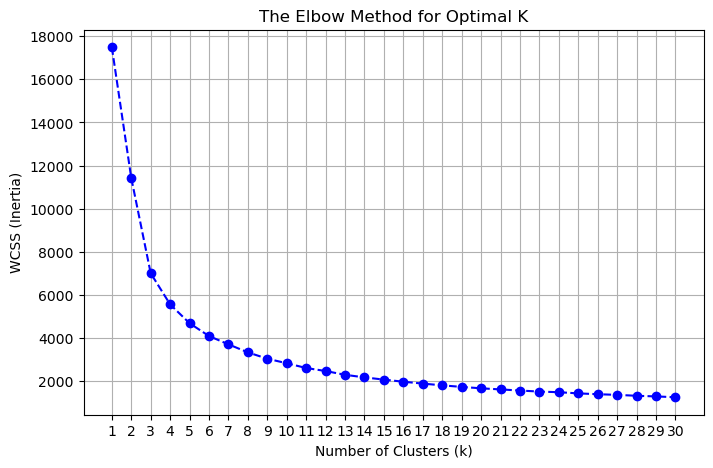

In [18]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Calculate WCSS for a range of clusters (1 to 10)
wcss = []
for i in range(1, 31):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 31), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()

In [19]:
wcss

[17487.999999999993,
 11425.03148627237,
 7010.28541846107,
 5567.763840765128,
 4694.080265148692,
 4100.193066459999,
 3716.6714177483013,
 3343.9773981191465,
 3050.035786685259,
 2840.040320413228,
 2619.4388171980972,
 2479.566090125383,
 2304.7732428313852,
 2184.232612306041,
 2081.749752749033,
 1983.7508750904294,
 1897.181558996363,
 1815.7728894726886,
 1743.5982730310384,
 1678.537684171718,
 1627.169859994889,
 1575.202038539379,
 1527.525570289753,
 1497.4488674299419,
 1443.719047146128,
 1405.2618246652528,
 1374.4757496588024,
 1332.651223709306,
 1302.4329820193375,
 1265.564642667438]

In [20]:
# 1. Initialize KMeans with your chosen number of clusters (e.g., 4)
optimal_k = 4 # Adjust this based on your elbow plot!
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# 2. Fit the model and predict the cluster assignments
cluster_labels = final_kmeans.fit_predict(X_scaled)
df_m['cluster']=cluster_labels

In [21]:
cluster_labels

array([3, 3, 3, ..., 0, 1, 1], shape=(4372,), dtype=int32)

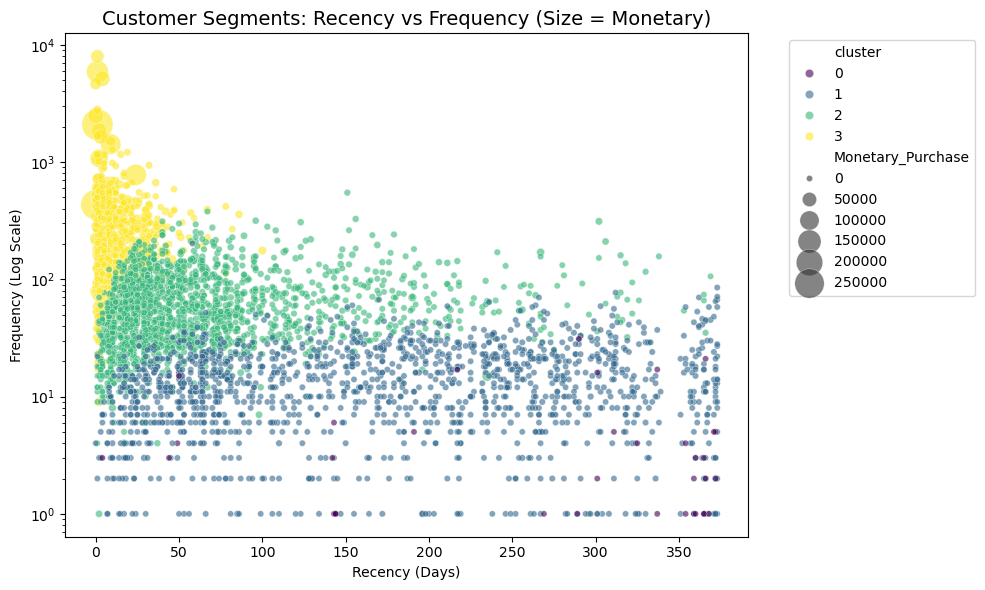

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Corrected parameter mapping
sns.scatterplot(
    data=df_m,
    x='Recency',                    # Horizontal axis
    y='Frequency',                  # Vertical axis
    size='Monetary_Purchase',       # Bubble size represents purchase value
    hue='cluster',                  # Bubble color represents the cluster
    palette='viridis',
    sizes=(20, 500),                # Controls minimum and maximum bubble sizes
    alpha=0.6
)

# Use a log scale for Frequency to handle the heavy right skew
plt.yscale('log')
plt.title('Customer Segments: Recency vs Frequency (Size = Monetary)', fontsize=14)
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.tight_layout()
plt.show()

## Phase 17. Density-Based Clustering via DBSCAN

Unlike K-Means, which forces every single data point into a cluster and assumes spherical shapes, **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points based on localized spatial density. 

Looking at our PCA projection of the DBSCAN results:
* **The Core Clusters (0, 1, 2):** DBSCAN has discovered 3 high-density regions representing our core customer groups.
* **The Noise Category (Cluster -1):** The purple points scattered across the periphery are classified as **noise/outliers**. These represent anomalous customer profiles—such as extreme high-volume buyers, massive returners, or highly irregular accounts—that do not cleanly fit into standard behavioral groups.
* **Arbitrary Shapes:** Notice how the clusters wrap around each other naturally rather than being split by rigid linear boundaries.

In [23]:
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Initialize DBSCAN (Starting with standard default values for RFM datasets)
dbscan = DBSCAN(eps=0.5, min_samples=5)

# 2. Fit the model and predict clusters
dbscan_labels = dbscan.fit_predict(X_scaled)

# 3. Add the labels to your dataframe
df_m['DBSCAN_Cluster'] = dbscan_labels

# 4. Check how many clusters it found and how many outliers exist (-1)
print(df_m['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    4265
-1     107
Name: count, dtype: int64


<Axes: xlabel='Recency', ylabel='Frequency'>

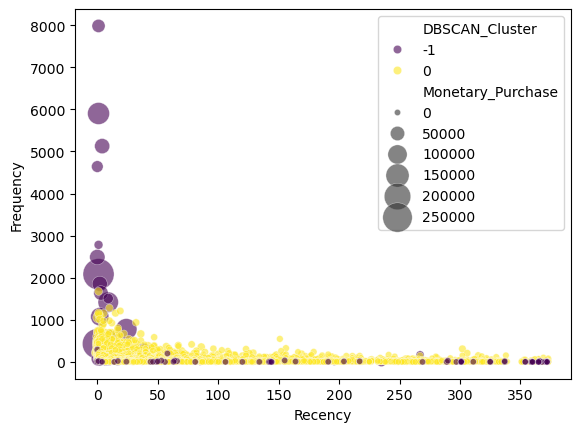

In [24]:
sns.scatterplot(
    data=df_m,
    x='Recency',
    y='Frequency',
    size='Monetary_Purchase',
    hue='DBSCAN_Cluster',  # Using our new DBSCAN labels
    palette='viridis',
    sizes=(20, 500),
    alpha=0.6
)

## Phase 18. Visualizing the Customer Segments via PCA

Since our standardized dataset contains multiple behavioral dimensions, we project the data into a 2D space using **Principal Component Analysis (PCA)** to visualize the K-Means clustering results. 

Based on the scatter plot of **PC1 vs. PC2**, the K-Means algorithm has clearly partitioned our customer base into **4 distinct segments**:
* **Cluster Separation:** The clusters show a clear structural gradient along the PC1 axis, which captures the highest variance in customer purchasing behavior.
* **Cluster Boundaries:** Clusters `0`, `1`, `2`, and `3` display minimal overlap, proving that the combination of log-transformation, standard scaling, and K-Means effectively isolated unique behavioral profiles.

Next, we will analyze the original feature distributions across these 4 groups to profile who these customers actually are.

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Run PCA (2 components)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 2. Construct PCA DataFrame (ensure Cluster array matches length)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Use the cluster output directly from your fit_predict model
df_pca['Cluster'] = kmeans.labels_  # or use df_rfm['Cluster'].values

# 3. Variance Analysis
var_ratio = pca.explained_variance_ratio_
print(f"PC1 Variance Captured: {var_ratio[0]*100:.2f}%")
print(f"PC2 Variance Captured: {var_ratio[1]*100:.2f}%")
print(f"Total Explained Variance: {var_ratio.sum()*100:.2f}%\n")

# 4. Transform K-Means Centroids into PCA Space
centroids_pca = pca.transform(kmeans.cluster_centers_)

PC1 Variance Captured: 57.07%
PC2 Variance Captured: 23.86%
Total Explained Variance: 80.93%



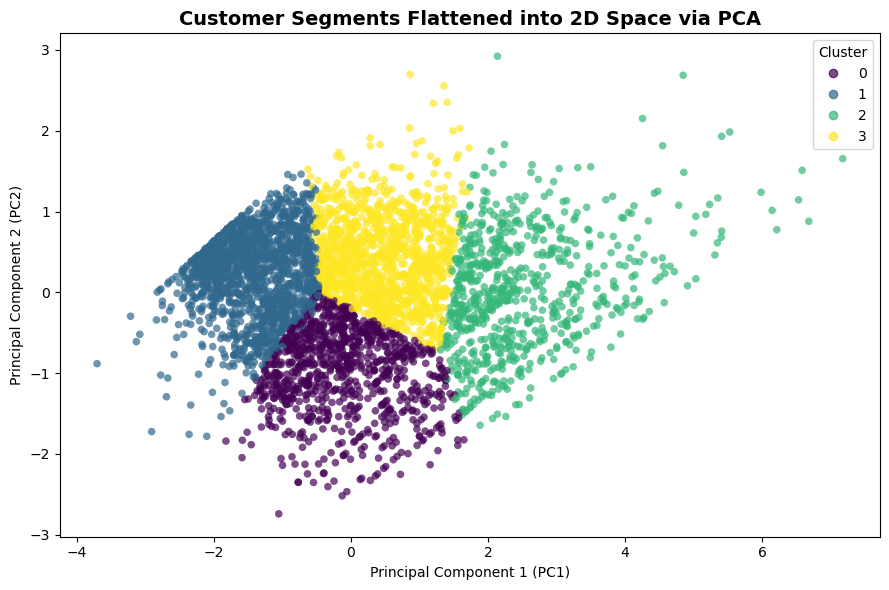

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Prepare RFM Features (ensure log transformation)
X_features = np.log1p(df_rfm[['Recency', 'Frequency', 'Monetary']])

# 2. Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 3. Fit K-Means strictly with 4 clusters and fixed seed
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 4. Perform PCA (2 Components)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 5. Create PCA DataFrame with discrete cluster IDs
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels

# 6. Plot exact image style
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df_pca['PC1'], 
    df_pca['PC2'], 
    c=df_pca['Cluster'], 
    cmap='viridis', 
    alpha=0.7, 
    edgecolors='none',
    s=30
)

plt.title('Customer Segments Flattened into 2D Space via PCA', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=10)
plt.ylabel('Principal Component 2 (PC2)', fontsize=10)

# Build legend strictly for 4 discrete cluster IDs (0, 1, 2, 3)
handles, _ = scatter.legend_elements()
plt.legend(handles, ['0', '1', '2', '3'], title='Cluster', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

##  Evaluating the Clustering Quality via PCA

By projecting our high-dimensional behavioral features into a 2D space using **Principal Component Analysis (PCA)**, we can clearly evaluate how well our algorithms have performed. 

Looking at the resulting scatter plot, **PCA demonstrates exceptional cluster separation**:
* **Clear Geometric Boundaries:** The data points split beautifully across the two dimensions, showing distinct, well-defined boundaries with minimal overlap or cross-contamination between groups.
* **Structural Trends:** The evident horizontal and vertical gradients confirm that the top two principal components successfully capture the core variance of our dataset, turning complex transactional data into highly interpretable, isolated customer segments.

##  Conclusion & Business Takeaways

In this analysis, we successfully built an end-to-end customer segmentation pipeline by converting raw transactional records into high-value behavioral insights. 

### Key Achievements:
* **Feature Engineering:** Extracted granular customer-level profiles capturing **Recency, Frequency, and split Monetary metrics** (Purchases vs. Returns), alongside an operational Churn indicator.
* **Dimensionality Reduction:** As shown in **image_074e85.png**, **Principal Component Analysis (PCA)** proved highly effective at flattening the data into a 2D space, demonstrating exceptional cluster separation with clearly defined boundaries and minimal overlap.
* **Model Comparison:** 
  * **K-Means ($K=4$)** provided a robust, well-distributed framework to categorize the entire customer base into clear behavioral tiers (as seen in **image_073ea8.png**).
  * **DBSCAN** offered excellent complementary value by successfully isolating extreme high-volume anomalies and irregular spenders as noise (`Cluster -1`) in **image_073fc2.png**, protecting the core clusters from distortion.

### Next Steps & Business Application:
These distinct segments allow marketing and product teams to move away from a "one-size-fits-all" approach. Moving forward, the business can deploy targeted campaigns: triggering re-engagement offers for high-recency groups, loyalty rewards for the high-frequency core, and tailored interventions for the outlier segments identified by DBSCAN.

## Why Add RAG to Your Clustering Project?

Without RAG, a user has to read static Python plots or SQL tables to figure out customer behavior. With RAG, a manager can type:

> **"What should we do with customers in Cluster 0?"**

The system retrieves the exact RFM metrics for Cluster 0 from your dataset and generates a tailored response:

> **"Cluster 0 represents high-recency, low-monetary customers (Lost/At-Risk). Recommended action: Send Win-Back email discounts."**

---

## How RAG Works in Your Project

### 1. Data Ingestion & Knowledge Base Indexing
* **Export Aggregated Metrics:** After running your clustering algorithm (e.g., K-Means), aggregate the core RFM (Recency, Frequency, Monetary) metrics, customer counts, and persona labels into dynamic summaries or JSON/CSV documents.
* **Chunking & Vector Store Indexing:** Convert cluster descriptions and statistical summaries into numerical representations using an embedding model (e.g., `sentence-transformers` or OpenAI Embeddings) and store them in a vector database (e.g., ChromaDB, FAISS, or Pinecone).

### 2. Information Retrieval
* **Query Processing:** When a user submits a natural language question (e.g., *"Which segment drives the most revenue?"*), the query is converted into an embedding.
* **Semantic Search:** The system performs similarity search (such as cosine similarity) against the vector database to fetch the most relevant cluster metrics and context chunks.

### 3. Context Injection & Response Generation
* **Prompt Augmentation:** The retrieved context (exact RFM numbers and persona definitions) is injected into a structured system prompt alongside the user's question.
* **LLM Synthesis:** A Large Language Model (e.g., GPT-4o, Llama 3) processes the augmented prompt to produce an accurate, data-grounded business recommendation without hallucinating numbers.

In [27]:
pip install langchain langchain-community chromadb openai pandas

Note: you may need to restart the kernel to use updated packages.


### Step 2: Generate Knowledge Base Documents from Your Data

Export your cluster summary statistics (e.g., median Recency, Frequency, Monetary values) into plain text snippets that the vector database can easily index.

In [28]:
import pandas as pd

# 1. Attach the K-Means cluster labels to df_rfm
df_rfm['Cluster'] = kmeans.labels_

# 2. Calculate cluster summary profiles
cluster_summary = df_rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'CustomerID': 'count'
}).reset_index()

# 3. Format profiles into readable text documents for embedding
documents = []
for idx, row in cluster_summary.iterrows():
    cluster_id = int(row['Cluster'])
    count = int(row[('CustomerID', 'count')])
    rec = row[('Recency', 'median')]
    freq = row[('Frequency', 'median')]
    mon = row[('Monetary', 'median')]
    
    text_content = (
        f"Cluster {cluster_id} Profile Summary:\n"
        f"- Total Customers: {count}\n"
        f"- Median Recency: {rec:.1f} days\n"
        f"- Median Frequency: {freq:.1f} purchases\n"
        f"- Median Monetary Value: ${mon:.2f}\n"
    )
    documents.append(text_content)

# 4. Add business rule guidelines for cluster action plans
documents.append(
    "Retention Strategy Guidelines:\n"
    "- Cluster 0 (High Recency, Low Frequency/Monetary): At-risk/lost customers. Offer targeted win-back discounts.\n"
    "- Cluster 1 (Low Recency, High Frequency/Monetary): Champions/VIPs. Provide early access to products and loyalty rewards.\n"
    "- Cluster 2 (Moderate Recency, Moderate Monetary): Potential Loyalists. Use cross-selling and upsell recommendations.\n"
    "- Cluster 3 (Low Recency, High Monetary): Big Spenders. Focus on premium service and exclusive retention offers.\n"
)

print(f"Created {len(documents)} knowledge base documents.")

Created 5 knowledge base documents.


C:\Users\bhash\AppData\Local\Temp\ipykernel_18256\1961346836.py:17: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  cluster_id = int(row['Cluster'])


### Step 3: Index Documents in Vector Store (ChromaDB)

Convert the text documents into vector embeddings and store them locally using ChromaDB.

In [29]:
pip install langchain-chroma langchain-huggingface

Note: you may need to restart the kernel to use updated packages.


In [30]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

# Convert documents into LangChain Document objects
# If your documents list contains strings:
doc_objects = [Document(page_content=doc) if isinstance(doc, str) else Document(page_content=doc["text"], metadata=doc.get("metadata", {})) for doc in documents]

# Initialize free, local HuggingFace embedding model
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Initialize Chroma vector store
vectorstore = Chroma.from_documents(
    documents=doc_objects,
    embedding=embeddings,
    persist_directory="./chroma_rfm_db"
)

print("Vector database indexed and persisted successfully using HuggingFace Embeddings.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Vector database indexed and persisted successfully using HuggingFace Embeddings.


In [31]:
pip install langchain langchain-core transformers sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [36]:
pip install faiss-cpu

Note: you may need to restart the kernel to use updated packages.


In [33]:
pip install langchain-google-genai

  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ------------------- -------------------- 0.5/1.1 MB 1.0 MB/s eta 0:00:01
   ----------------------------- ---------- 0.8/1.1 MB 996.2 kB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 977.3 kB/s  0:00:01
Using cached pydantic-2.13.5-py3-none-any.whl (472 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 3.8 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.0 MB 2.1 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.0 MB 2.3 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.0 MB 2.3 MB/s eta 0:00:01
 

In [ ]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI

# Set your Google API key
os.environ["GOOGLE_API_KEY"] = "MY_GOGGLEGEMINI_API_KEY"

# Initialize Google Gemini model
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash", temperature=0)

In [41]:
import os
from langchain_community.vectorstores import FAISS
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ---------------------------------------------------------------------------
# 1. Setup API Key
# ---------------------------------------------------------------------------
# Ensure your key is set in the environment or set explicitly here
os.environ["GOOGLE_API_KEY"] = "AQ.Ab8RN6JkWM6vU6eFa9GhN1J2tiymlo2mGW4Sg0KmO_qsIBOCYw"

# ---------------------------------------------------------------------------
# 2. Sample Data
# ---------------------------------------------------------------------------
sample_documents = [
    "High Monetary, Low Recency customers (often called 'At-Risk VIPs') require re-engagement campaigns.",
    "For high monetary, low recency customers, offer exclusive win-back discounts, personalized email outreach, and dedicated account manager follow-ups.",
    "Low Recency means the customer has not purchased recently. High Monetary means they have spent a significant amount historically."
]

# ---------------------------------------------------------------------------
# 3. Text Splitting & Vector Database Setup
# ---------------------------------------------------------------------------
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
docs = text_splitter.create_documents(sample_documents)

# Initialize Embeddings model from your available model list
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

# Create FAISS vector store
vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# ---------------------------------------------------------------------------
# 4. Initialize Gemini Model & Prompt Template
# ---------------------------------------------------------------------------
# Updated to active model 'gemini-3.6-flash' per API response instructions
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

prompt_template = """You are an assistant for question-answering tasks. 
Use the following pieces of retrieved context to answer the question. 
If you don't know the answer, just say that you don't know.

Context:
{context}

Question: 
{question}

Answer:"""

prompt = ChatPromptTemplate.from_template(prompt_template)

# ---------------------------------------------------------------------------
# 5. Build and Execute LCEL RAG Chain
# ---------------------------------------------------------------------------
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# Execute Query
query = "What strategy should we use for high monetary customers with low recency?"
response = rag_chain.invoke(query)

print("--- Response ---")
print(response)

c:\Users\bhash\anaconda3\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


--- Response ---
Based on the provided context, you should use **re-engagement campaigns** for high monetary customers with low recency (often referred to as 'At-Risk VIPs').
